📁 Raw data folder: /Users/jts/Desktop/AI Neural Networks/Project/raw_data/anilist_data_20260311_130200
📁 Visualizations folder: /Users/jts/Desktop/AI Neural Networks/Project/visualizations
📁 Processed folder: /Users/jts/Desktop/AI Neural Networks/Project/processed_data

📊 Dataset Summary:
   Total users: 75
   Total entries: 61,693
   Average entries per user: 822.6
   Min entries: 71
   Max entries: 3166

🔍 Checking user JSON files:
----------------------------------------
✅ Found 75 user files

🎉 All user files found! You can now load individual user data.

📖 Loading sample user: matchai
----------------------------------------
   User ID: 2
   Total entries: 325
   Collection date: 2026-03-11

   Entry status breakdown:
      PLANNING: 64
      COMPLETED: 219
      DROPPED: 22
      PAUSED: 3
      CURRENT: 17
✅ Saved visualization to: /Users/jts/Desktop/AI Neural Networks/Project/visualizations/user_distribution.png


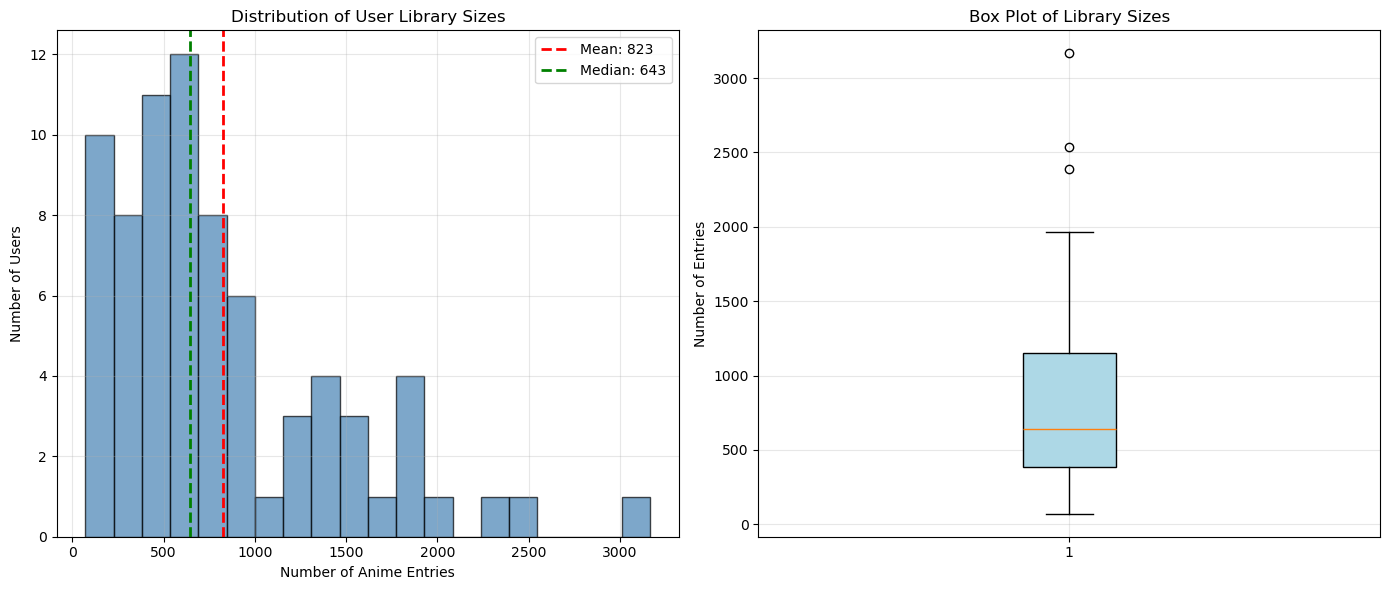


🎯 Top 10 Users by Entries:
----------------------------------------
    1. IssacandAsimov        3166 entries
    2. Gigg44                2536 entries
    3. WikyWill              2391 entries
    4. Juramate              1968 entries
    5. Robin                 1903 entries
    6. Inorinne              1877 entries
    7. Tigga                 1817 entries
    8. Killex                1806 entries
    9. Jaka                  1773 entries
   10. YumeTsuretekita       1569 entries
✅ Saved top users chart to: /Users/jts/Desktop/AI Neural Networks/Project/visualizations/top_users.png


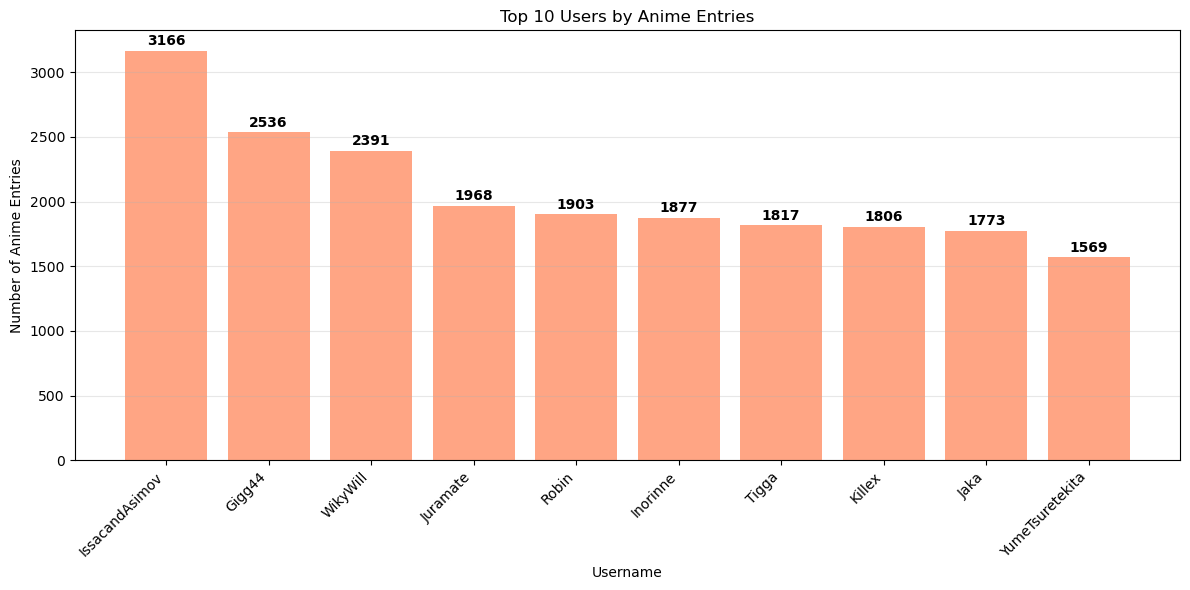


📈 Detailed Statistics:
----------------------------------------
   count     :       75.0
   mean      :      822.6
   std       :      637.1
   min       :       71.0
   25%       :      382.0
   50%       :      643.0
   75%       :     1154.0
   max       :     3166.0

✅ Saved processed user summary to: /Users/jts/Desktop/AI Neural Networks/Project/processed_data/user_summary_processed.csv


In [2]:
# %% [markdown]
# # AniList Data Exploration
# **Date**: March 11, 2026
# **Dataset**: 75 users, 61,693 anime entries

# %%
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Setup paths
project_folder = Path("/Users/jts/Desktop/AI Neural Networks/Project")
raw_data_folder = project_folder / "raw_data/anilist_data_20260311_130200"
viz_folder = project_folder / "visualizations"
processed_folder = project_folder / "processed_data"

# Create folders if they don't exist
viz_folder.mkdir(exist_ok=True, parents=True)
processed_folder.mkdir(exist_ok=True, parents=True)

print(f"📁 Raw data folder: {raw_data_folder}")
print(f"📁 Visualizations folder: {viz_folder}")
print(f"📁 Processed folder: {processed_folder}")

# Load manifest
manifest_file = raw_data_folder / "manifest.json"
with open(manifest_file, 'r') as f:
    manifest = json.load(f)

# Create DataFrame from manifest (not from files yet)
df_users = pd.DataFrame(manifest['collected_users'])

print(f"\n📊 Dataset Summary:")
print(f"   Total users: {len(df_users)}")
print(f"   Total entries: {manifest['summary']['total_entries_sum']:,}")
print(f"   Average entries per user: {manifest['summary']['avg_entries_per_user']:.1f}")
print(f"   Min entries: {manifest['summary']['min_entries']}")
print(f"   Max entries: {manifest['summary']['max_entries']}")

# %%
# Check which user files actually exist
print("\n🔍 Checking user JSON files:")
print("-" * 40)

existing_files = []
missing_files = []

for user in manifest['collected_users']:
    # Construct correct path
    correct_path = raw_data_folder / f"user_{user['id']}_{user['name']}.json"
    
    if correct_path.exists():
        existing_files.append(user['name'])
    else:
        missing_files.append(user['name'])

print(f"✅ Found {len(existing_files)} user files")
if missing_files:
    print(f"⚠️  Missing {len(missing_files)} files")

if len(existing_files) == len(manifest['collected_users']):
    print("\n🎉 All user files found! You can now load individual user data.")
else:
    print("\n⚠️  Some files are missing. Let's check what's in the folder:")
    
    # List what's actually in the folder
    all_files = list(raw_data_folder.glob("user_*.json"))
    print(f"\n📋 Files in {raw_data_folder}:")
    for f in all_files[:10]:  # Show first 10
        print(f"   {f.name}")
    if len(all_files) > 10:
        print(f"   ... and {len(all_files)-10} more")

# %%
# Load a sample user to verify data structure
if existing_files:
    sample_user = manifest['collected_users'][0]
    sample_file = raw_data_folder / f"user_{sample_user['id']}_{sample_user['name']}.json"
    
    print(f"\n📖 Loading sample user: {sample_user['name']}")
    print("-" * 40)
    
    with open(sample_file, 'r', encoding='utf-8') as f:
        user_data = json.load(f)
    
    print(f"   User ID: {user_data['user_id']}")
    print(f"   Total entries: {user_data['total_entries']}")
    print(f"   Collection date: {user_data['collection_date'][:10]}")
    
    # Count entries by status
    status_counts = {}
    for lst in user_data['data'].get('lists', []):
        for entry in lst.get('entries', []):
            status = entry.get('status', 'UNKNOWN')
            status_counts[status] = status_counts.get(status, 0) + 1
    
    print("\n   Entry status breakdown:")
    for status, count in status_counts.items():
        print(f"      {status}: {count}")
else:
    print("\n⚠️ No user files found to sample")

# %%
# Distribution of entries (from manifest)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(df_users['entries'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(df_users['entries'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f"Mean: {df_users['entries'].mean():.0f}")
plt.axvline(df_users['entries'].median(), color='green', linestyle='--', linewidth=2, 
            label=f"Median: {df_users['entries'].median():.0f}")
plt.xlabel('Number of Anime Entries')
plt.ylabel('Number of Users')
plt.title('Distribution of User Library Sizes')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
boxplot = plt.boxplot(df_users['entries'], patch_artist=True)
boxplot['boxes'][0].set_facecolor('lightblue')
plt.title('Box Plot of Library Sizes')
plt.ylabel('Number of Entries')
plt.grid(True, alpha=0.3)

plt.tight_layout()

# Save the figure
viz_file = viz_folder / 'user_distribution.png'
plt.savefig(viz_file, dpi=150, bbox_inches='tight')
print(f"✅ Saved visualization to: {viz_file}")
plt.show()

# %%
# Top 10 users by entries
print("\n🎯 Top 10 Users by Entries:")
print("-" * 40)
top_users = df_users.nlargest(10, 'entries')[['name', 'entries']]
for i, (idx, row) in enumerate(top_users.iterrows(), 1):
    print(f"   {i:2d}. {row['name']:<20} {row['entries']:5d} entries")

# %%
# Create a bar chart of top users
plt.figure(figsize=(12, 6))
top_10 = df_users.nlargest(10, 'entries')
bars = plt.bar(range(10), top_10['entries'].values, color='coral', alpha=0.7)
plt.xticks(range(10), top_10['name'].values, rotation=45, ha='right')
plt.xlabel('Username')
plt.ylabel('Number of Anime Entries')
plt.title('Top 10 Users by Anime Entries')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, entries in zip(bars, top_10['entries'].values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, 
             f'{entries}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
viz_file2 = viz_folder / 'top_users.png'
plt.savefig(viz_file2, dpi=150, bbox_inches='tight')
print(f"✅ Saved top users chart to: {viz_file2}")
plt.show()

# %%
# Summary statistics
print("\n📈 Detailed Statistics:")
print("-" * 40)
stats = df_users['entries'].describe()
for stat_name, stat_value in stats.items():
    print(f"   {stat_name:10s}: {stat_value:10.1f}")

# %%
# Save processed summary
df_users.to_csv(processed_folder / 'user_summary_processed.csv', index=False)
print(f"\n✅ Saved processed user summary to: {processed_folder / 'user_summary_processed.csv'}")